# Soliqua

## 0. 环境准备

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置 rcParams 默认值
import matplotlib
matplotlib.rc("font",family='Microsoft YaHei')

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc("axes",
        labelweight="bold", # 标签粗细
        labelsize="large", # 标签字体
        titleweight="bold", # 标题粗细
        titlesize=16, # 标题字体
        titlepad=10,
      )
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

In [3]:
def fill_features(df_pred: pd.DataFrame, df_train: pd.DataFrame = None,
                  train_columns: pd.Index = None) -> pd.DataFrame:
    """按列名规则做缺失值填充，并将列对齐到训练集。
    - 列名含 '环比' → 训练集中位数
    - 列名含 '斜率' 或 'R方' → 0
    - 其他有值列 → 训练集均值
    - 全空列 / 训练集中未出现 → 0
    - 训练集中存在但当前样本没有的列（如 one-hot 缺失月份）→ 补 0
    """
    out = df_pred.copy()
    train_ref = df_train if df_train is not None else df_pred

    # 1) 缺失值填充
    for col in out.columns:
        if col in train_ref.columns:
            if train_ref[col].isna().all():
                out[col] = out[col].fillna(0)
            elif '环比' in col:
                out[col] = out[col].fillna(train_ref[col].median())
            elif '斜率' in col or 'R方' in col:
                out[col] = out[col].fillna(0)
            else:
                out[col] = out[col].fillna(train_ref[col].mean())
        else:
            out[col] = out[col].fillna(0)

    # 2) 列对齐到训练集
    if train_columns is not None:
        for col in train_columns:
            if col not in out.columns:
                out[col] = 0
        # 丢弃训练时没有的列（保持顺序与训练一致）
        out = out[train_columns]

    return out


def predict_ensemble(models: list, X_scaled: np.ndarray) -> np.ndarray:
    """对 HORIZON 个模型逐一预测，组装为长度 HORIZON 的预测向量。"""
    return np.array([m.predict(X_scaled)[0] for m in models])


def chain_mom_to_abs(base_sale: float, mom_rates: np.ndarray) -> np.ndarray:
    """从基准销量 + 环比百分比数组递归生成 HORIZON 个月的绝对值销量。"""
    out, current = [], float(base_sale)
    for r in mom_rates:
        current = current * (1.0 + r / 100.0)
        out.append(current)
    return np.array(out)


def lookup_qty(df: pd.DataFrame, date) -> float:
    """按月查销量"""
    df_idx = df.set_index('bizym') if 'bizym' in df.columns else df
    v = df_idx['qty'].get(date, np.nan)
    return float(v) if pd.notna(v) else np.nan


def mix_two_way(pred_mom: np.ndarray, pred_abs: np.ndarray,
                w_mom: float, w_abs: float) -> np.ndarray:
    """两路加权：pred_ens = w_mom * pred_mom + w_abs * pred_abs"""
    return w_mom * pred_mom + w_abs * pred_abs

def mix_three_way(pred_mom: np.ndarray, pred_abs: np.ndarray, pred_yoy: np.ndarray, 
                w_mom: float, w_abs: float, w_yoy: float) -> np.ndarray:
    """三路加权：pred_ens = w_mom * pred_mom + w_abs * pred_abs + w_yoy * pred_yoy"""
    pred_ensemble = np.zeros(6)
    for i in range(6):
        if not np.isnan(pred_yoy[i]):
            pred_ensemble[i] = (w_mom * pred_mom[i] + 
                            w_abs * pred_abs[i] + 
                            w_yoy * pred_yoy[i])
        else:
            # 如果没有去年数据,只用环比和绝对值
            pred_ensemble[i] = (w_mom/(w_mom+w_abs)) * pred_mom[i] + (w_abs/(w_mom+w_abs)) * pred_abs[i]
    return pred_ensemble

In [ ]:
TRAIN_START = pd.Timestamp('2024-10-01')
TRAIN_END = pd.Timestamp('2025-10-01')
PRED_START = pd.Timestamp('2026-04-01')

## 1. 数据接入

###  1.1. 读取数据

In [4]:
from pathlib import Path

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'code').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate repository root containing code/ and data/')

REPO_ROOT = find_repo_root()
df_raw = pd.read_csv(REPO_ROOT / 'data' / 'sales_6m_monthly.csv')
df_raw.head()

,bizym,prodmdmcode,tomdphncode,qty
0,202401,170,PHN00010641,2.0
1,202401,170,PHN00051079,0.0
2,202401,170,PHN00235194,47.0
3,202401,170,PHN00258420,36.0
4,202401,170,PHN00272163,3.0


###  1.2. 格式转换

In [5]:
# 产品编码转换为字符型
df_raw['prodmdmcode'] = df_raw['prodmdmcode'].astype(str)

# 日期转换为字符型
df_raw['bizym'] = pd.to_datetime(df_raw['bizym'].astype(str), format='%Y%m', errors='coerce')

# 销量转换为数值型
if 'qty' in df_raw.columns:
    df_raw['qty'] = pd.to_numeric(df_raw['qty'], errors='coerce')

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59762 entries, 0 to 59761
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   bizym        59762 non-null  datetime64[ns]
 1   prodmdmcode  59762 non-null  object        
 2   tomdphncode  59762 non-null  object        
 3   qty          59762 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1.8+ MB


## 2. 170规格预测

### 2.1. by月聚合

In [6]:
df_monthly = (df_raw[df_raw['prodmdmcode']=='170'].groupby('bizym', as_index=False)
    .agg(qty=('qty', 'sum'))
    .sort_values('bizym')
    .reset_index(drop=True)
)
df_monthly.head()

,bizym,qty
0,2024-01-01,18037.0
1,2024-02-01,14715.0
2,2024-03-01,26926.0
3,2024-04-01,26811.0
4,2024-05-01,37483.0


In [7]:
fig = px.scatter(data_frame=df_monthly, x=df_monthly['bizym'], y=df_monthly['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=df_monthly['bizym'], 
                        y=df_monthly['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False
                        ))

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2025-01-01'), x1=pd.Timestamp('2025-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",  # 关键：yref=paper 让 y 坐标用 0-1 相对值
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2026-01-01'), x1=pd.Timestamp('2026-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)


fig.add_annotation(
    x=pd.Timestamp('2025-01-01'), y=1,
    xref="x", yref="paper",
    text="2025", showarrow=False,
    yshift=5,  # 文字位置稍微上移
    font=dict(size=12, color='#E74C3C')
)

fig.add_annotation(
    x=pd.Timestamp('2026-01-01'), y=1,
    xref="x", yref="paper",
    text="2026", showarrow=False,
    yshift=5,
    font=dict(size=12, color='#E74C3C')
)


fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title='Soliqua 1:1 (170)',
                xaxis_tickangle=45,
                width=800, 
                height=400 )

In [8]:
print(f"✓ 月度数据准备完成，共{len(df_monthly)}个月")
print(f"✓ 时间范围: {df_monthly['bizym'].min().strftime('%Y-%m')} ~ {df_monthly['bizym'].max().strftime('%Y-%m')}")

✓ 月度数据准备完成，共29个月
✓ 时间范围: 2024-01 ~ 2026-05


### 2.2. 历史同月环比统计

In [9]:
# 计算环比增长率
df_monthly['mom'] = df_monthly['qty'].pct_change() * 100
df_monthly['month'] = df_monthly['bizym'].dt.month


# 统计历史同月环比模式
print(f"\n【历史同月环比增长率 - 统计信息】")
print("="*90)
month_mom_stats = df_monthly.groupby('month')['mom'].agg(['mean', 'median', 'std', 'count']).reset_index()
month_mom_stats


【历史同月环比增长率 - 统计信息】


,month,mean,median,std,count
0,1,46.013705,46.013705,5.403910,2
1,2,-25.071038,-19.883100,10.280992,3
2,3,67.362700,60.022013,13.536030,3
3,4,-7.971621,-10.536521,6.644367,3
4,5,15.649061,18.687707,25.809327,3
5,6,8.772482,8.772482,6.252487,2
6,7,-8.859308,-8.859308,17.659519,2
7,8,23.321928,23.321928,4.361572,2
8,9,27.429670,27.429670,14.735619,2
9,10,-36.812603,-36.812603,15.796643,2


### 2.3. 特征工程

In [10]:
def create_holistic_samples(df, target_date):
    """为指定预测起点创建未来6个月预测样本"""
    
    # 1. 准备月份索引
    future_months     = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    same_period_ly    = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    recent_6m         = pd.date_range(target_date - pd.DateOffset(months=5),  periods=6, freq='MS')
    future_month_nums = [m.month for m in future_months]
    
    # 2. 把 bizym 设为索引
    df_idx  = df.set_index('bizym')
    df_hist = df_idx[df_idx.index <= target_date]
    
    # 3. 一次性取出所有月份数据
    sales_ly, mom_ly = df_hist['qty'].reindex(same_period_ly), df_hist['mom'].reindex(same_period_ly)
    sales_re, mom_re = df_hist['qty'].reindex(recent_6m),      df_hist['mom'].reindex(recent_6m)
    
    # 4. 历史同月环比
    mom_by_month = df_hist.groupby(df_hist.index.month)['mom'].agg(['mean', 'median'])
    hist_mom_mean   = mom_by_month['mean'].reindex(future_month_nums).tolist()
    hist_mom_median = mom_by_month['median'].reindex(future_month_nums).tolist()
    
    # 5. 整体斜率与 R-squared
    def slope_r(y):
        y = np.asarray(y, dtype=float)
        mask = ~np.isnan(y)
        if mask.sum() < 2:
            return np.nan, np.nan
        s, _, r, _, _ = stats.linregress(np.arange(len(y))[mask], y[mask])
        return s, r
    
    slope_ly, r_ly     = slope_r(sales_ly.values)
    slope_rec, r_rec   = slope_r(sales_re.values)
    
    # 6. 预测起点销量
    base_sale = float(df_hist['qty'].get(target_date, np.nan))
    
    # 7. 组装整体特征
    features = {
        'ly_销量_均值':   np.nanmean(sales_ly),  'ly_销量_总和':   np.nansum(sales_ly),
        'ly_销量_标准差': np.nanstd(sales_ly),   'ly_环比_均值':   np.nanmean(mom_ly),
        'ly_环比_中位数': np.nanmedian(mom_ly),  'ly_整体斜率':    slope_ly,
        'ly_R方':         r_ly,
        'rec_销量_均值':   np.nanmean(sales_re), 'rec_销量_总和':   np.nansum(sales_re),
        'rec_销量_标准差': np.nanstd(sales_re),  'rec_环比_均值':   np.nanmean(mom_re),
        'rec_环比_中位数': np.nanmedian(mom_re), 'rec_整体斜率':    slope_rec,
        'rec_R方':         r_rec,
        # 'base_销量': base_sale,
        '未来_起始月':     future_month_nums[0], '未来_结束月':     future_month_nums[-1],
    }
    
    # 月份 one-hot 编码
    month_names = ['jan','feb','mar','apr','may','jun',
                   'jul','aug','sep','oct','nov','dec']
    for i, m in enumerate(future_month_nums, 1):
        features[f'future_M{i}_is_{month_names[m-1]}'] = 1
    
    # 逐月细粒度特征
    for i in range(6):
        features[f'ly_M{i+1}_销量']                = sales_ly.iloc[i]
        features[f'ly_M{i+1}_环比']                = mom_ly.iloc[i]
        features[f'rec_M{i+1}_销量']               = sales_re.iloc[i]
        features[f'rec_M{i+1}_环比']               = mom_re.iloc[i]
        features[f'future_M{i+1}_hist_mom_mean']   = hist_mom_mean[i]
        features[f'future_M{i+1}_hist_mom_median'] = hist_mom_median[i]
    
    # 8. 提取目标
    targets_abs = df_idx['qty'].reindex(future_months).tolist()
    targets_mom = []
    prev = base_sale
    for s in targets_abs:
        if pd.notna(s) and pd.notna(prev) and prev > 0:
            targets_mom.append((s - prev) / prev * 100)
            prev = s
        else:
            targets_mom.append(np.nan)
    
    return features, targets_abs, targets_mom, future_months

In [12]:
train_dates = pd.date_range(TRAIN_START, TRAIN_END, freq='MS')

train_samples = []
train_targets_abs = []
train_targets_mom = []

for date in train_dates:
    features, targets_abs, targets_mom, _ = create_holistic_samples(df_monthly, date)
    
    # 检查 label 是否有值
    if not any(np.isnan(targets_abs)) and not any(np.isnan(targets_mom)):
        train_samples.append(features)
        train_targets_abs.append(targets_abs)
        train_targets_mom.append(targets_mom)
    else:
        nan_abs_idx = [i+1 for i, v in enumerate(targets_abs) if np.isnan(v)]
        nan_mom_idx = [i+1 for i, v in enumerate(targets_mom) if np.isnan(v)]
        raise ValueError(
            f"目标值不完整(起点日期: {date.strftime('%Y-%m')})；"
            f"销量缺失月份(第几个月): {nan_abs_idx}；"
            f"环比缺失月份(第几个月): {nan_mom_idx}。"
        )

print(f"✓ 生成{len(train_samples)}个训练样本")

# 转为DataFrame
train_X = pd.DataFrame(train_samples)
train_y_abs = np.array(train_targets_abs)
train_y_mom = np.array(train_targets_mom)

print(f"  特征维度: {train_X.shape}")
print(f"  特征数量: {train_X.shape[1]}")

✓ 生成13个训练样本
  特征维度: (13, 124)
  特征数量: 124


### 2.4. 缺失值填充

In [13]:
# 检查缺失值情况
nan_counts = train_X.isna().sum()
print(f"\n训练数据缺失值统计(前10个):")
if nan_counts.sum() > 0:
    for col, count in nan_counts[nan_counts > 0].head(10).items():
        print(f"  - {col}: {count}个缺失值")


训练数据缺失值统计(前10个):
  - future_M1_is_nov: 11个缺失值
  - future_M2_is_dec: 11个缺失值
  - future_M3_is_jan: 11个缺失值
  - future_M4_is_feb: 11个缺失值
  - future_M5_is_mar: 11个缺失值
  - future_M6_is_apr: 11个缺失值
  - ly_M1_销量: 2个缺失值
  - ly_M1_环比: 3个缺失值
  - future_M1_hist_mom_mean: 3个缺失值
  - future_M1_hist_mom_median: 3个缺失值


In [14]:
train_X_filled = train_X.copy()

for col in train_X_filled.columns:
    if train_X_filled[col].isna().all():
        train_X_filled[col] = 0
    elif '环比' in col: # 中位数填充
        if train_X_filled[col].notna().any():
            col_median = train_X_filled[col].median()
            n_missing = train_X_filled[col].isna().sum()
            if n_missing > 0:
                train_X_filled[col] = train_X_filled[col].fillna(col_median)
        else:
            train_X_filled[col] = 0
    elif '斜率' in col or 'R方' in col: # 0填充
        n_missing = train_X_filled[col].isna().sum()
        if n_missing > 0:
            train_X_filled[col] = train_X_filled[col].fillna(0)
    else:
        if train_X_filled[col].notna().any(): # 均值填充
            train_X_filled[col] = train_X_filled[col].fillna(train_X_filled[col].mean())
        else:
            train_X_filled[col] = 0

if train_X_filled.isna().sum().sum() == 0:
    print(f"\n✓ 缺失值填充完成")


✓ 缺失值填充完成


### 2.5. 标准化

In [15]:
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_filled)

print(f"✓ 特征标准化完成")

✓ 特征标准化完成


### 2.6. 模型训练

In [16]:
# 总共六个模型，分别对应T+i月

# 方案1: 预测绝对值(Ridge)
models_abs = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_abs[:, i])
    models_abs.append(model)

# 方案2: 预测环比增长率(Ridge)
models_mom = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_mom[:, i])
    models_mom.append(model)

print(f"\n✓ 6个绝对值Ridge模型训练完成(alpha=5.0)")
print(f"✓ 6个环比增长率Ridge模型训练完成(alpha=5.0)")


✓ 6个绝对值Ridge模型训练完成(alpha=5.0)
✓ 6个环比增长率Ridge模型训练完成(alpha=5.0)


### 2.7. 最优权重

In [18]:
backtest_end = PRED_START - pd.DateOffset(months=6)
backtest_start = pd.Timestamp('2025-01-01')

# 检查回测窗口是否有效
if backtest_end < backtest_start:
    print(f"⚠️ 回测窗口无效，请调整回测起点")

backtest_dates   = pd.date_range(backtest_start, backtest_end, freq='MS')

weight_candidates = [0.5, 0.6, 0.7, 0.8, 0.9]

print(f"\n[170] 回测配置:")
print(f"  预测起点: {PRED_START.strftime('%Y-%m')}")
print(f"  回测窗口: {backtest_dates[0].strftime('%Y-%m')} ~ {backtest_dates[-1].strftime('%Y-%m')} ({len(backtest_dates)}个月)")
print(f"  权重候选: {weight_candidates}")


[170] 回测配置:
  预测起点: 2026-04
  回测窗口: 2025-01 ~ 2025-10 (10个月)
  权重候选: [0.5, 0.6, 0.7, 0.8, 0.9]


In [ ]:
# ============================================================
# 170 权重选择 Pipeline
# ============================================================

HORIZON = 6  # 预测步长

# ---------- 1. 对每个回测起点预测未来6个月数量&环比推算数量 ----------
per_date = {}  # bt_date -> (pred_abs, pred_from_mom, actuals, future_months)
for bt_date in backtest_dates:
    feats, abs_t, _, future = create_holistic_samples(df_monthly, bt_date)
    if any(pd.isna(abs_t)):
        print(f"  ⚠️ 跳过 {bt_date.strftime('%Y-%m')}: 未来{HORIZON}个月数据不完整")
        continue
    X_filled = fill_features(
        pd.DataFrame([feats]),
        df_train=train_X_filled,
        train_columns=train_X_filled.columns,
    )
    X_scaled   = scaler_X.transform(X_filled)
    pred_abs   = predict_ensemble(models_abs, X_scaled)
    pred_mom_r = predict_ensemble(models_mom, X_scaled)
    base_sale  = lookup_qty(df_monthly, bt_date)
    pred_from_mom = chain_mom_to_abs(base_sale, pred_mom_r)
    per_date[bt_date] = (pred_abs, pred_from_mom, np.array(abs_t), future)

print(f"  ✓ 已为 {len(per_date)} 个回测起点生成预测缓存")

# ---------- 2. 评估权重组合 ----------
results = []
details_per_weight = {}  # w_mom -> list of dict

for w_mom in weight_candidates:
    w_abs = 1.0 - w_mom
    all_errors, detail_rows = [], []
    for bt_date, (pred_abs, pred_from_mom, actuals, future) in per_date.items():
        pred_ens = mix_two_way(pred_from_mom, pred_abs, w_mom, w_abs)
        e = np.abs((pred_ens - actuals) / actuals)
        all_errors.extend(e)
        for i in range(HORIZON):
            detail_rows.append({
                '回测起点': bt_date, '预测月份': future[i],
                '预测值': pred_ens[i], '实际值': actuals[i],
                'MAPE': e[i] * 100,
            })
    avg_mape = np.mean(all_errors) * 100
    results.append({
        'w_mom': w_mom, 'w_abs': w_abs,
        'MAPE': avg_mape, 'n_samples': len(all_errors) // HORIZON,
    })
    details_per_weight[w_mom] = detail_rows
    print(f"  权重 环比{w_mom:.1f}+绝对值{w_abs:.1f}: MAPE={avg_mape:.2f}% (样本数={len(all_errors)//HORIZON})")

# ---------- 3. 选择最优权重 ----------
if results:
    results_df = pd.DataFrame(results)
    best_row   = results_df.loc[results_df['MAPE'].idxmin()]
    print(f"\n最优权重: 环比{best_row['w_mom']:.1f} / 绝对值{best_row['w_abs']:.1f}, "
          f"MAPE={best_row['MAPE']:.2f}%")

    optimal_w_mom = float(best_row['w_mom'])
    optimal_w_abs = float(best_row['w_abs'])
    backtest_details = details_per_weight[optimal_w_mom]
else:
    print("⚠️ 回测无结果，使用默认权重 0.7/0.3")
    optimal_w_mom, optimal_w_abs = 0.7, 0.3
    backtest_details = []

  ✓ 已为 10 个回测起点生成预测缓存
  权重 环比0.5+绝对值0.5: MAPE=4.69% (样本数=10)
  权重 环比0.6+绝对值0.4: MAPE=4.92% (样本数=10)
  权重 环比0.7+绝对值0.3: MAPE=5.19% (样本数=10)
  权重 环比0.8+绝对值0.2: MAPE=5.52% (样本数=10)
  权重 环比0.9+绝对值0.1: MAPE=5.91% (样本数=10)

最优权重: 环比0.5 / 绝对值0.5, MAPE=4.69%


### 2.8. 预测未来6个月

In [21]:
feats_pred, _, _, future_months = create_holistic_samples(df_monthly, PRED_START)
X_pred_filled = fill_features(
    pd.DataFrame([feats_pred]),
    df_train=train_X_filled,
    train_columns=train_X_filled.columns,
)
X_pred_scaled = scaler_X.transform(X_pred_filled)
pred_abs      = predict_ensemble(models_abs, X_pred_scaled)
pred_mom_r    = predict_ensemble(models_mom, X_pred_scaled)
base_sale     = lookup_qty(df_monthly, PRED_START)
pred_from_mom = chain_mom_to_abs(base_sale, pred_mom_r)
pred_ensemble = mix_two_way(pred_from_mom, pred_abs, optimal_w_mom, optimal_w_abs)


# 输出结果
print("\n【预测结果】")
print("="*110)
print(f"{'month':<12} {'绝对值预测':>12} {'环比预测':>12} {'最优权重预测':>12} {'预测环比%':>12}")
print("="*110)

for i, month in enumerate(future_months):
    if i == 0:
        mom_pct = (pred_ensemble[i] - base_sale) / base_sale * 100
    else:
        mom_pct = (pred_ensemble[i] - pred_ensemble[i-1]) / pred_ensemble[i-1] * 100
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_abs[i]:>15.0f} {pred_from_mom[i]:>15.0f} {pred_ensemble[i]:>15.0f} {mom_pct:>12.2f}%")

print("="*110)
print(f"{'6个月总计':<12} {pred_abs.sum():>12.0f} {pred_from_mom.sum():>15.0f} {pred_ensemble.sum():>15.0f}")


【预测结果】
month               绝对值预测         环比预测       最优权重预测        预测环比%
2026-05               188818          174481          181650         5.26%
2026-06               218707          243339          231023        27.18%
2026-07               190693          159054          174873       -24.30%
2026-08               180349          185197          182773         4.52%
2026-09               278207          323454          300830        64.59%
2026-10               170458           91607          131033       -56.44%
6个月总计             1227232         1177132         1202182


### 2.9. 可视化观察合理性

In [26]:
# 历史数据
plot_df_170 = df_monthly[df_monthly['bizym']<=PRED_START][['bizym', 'qty']].copy()
plot_df_170['年份'] = plot_df_170['bizym'].dt.year
plot_df_170['月份'] = plot_df_170['bizym'].dt.month
plot_df_170['类型'] = '历史实际值'

# 添加预测数据
pred_data = pd.DataFrame({
    'bizym': future_months,
    'qty': pred_ensemble,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值'
})
plot_df_170 = pd.concat([plot_df_170, pred_data], ignore_index=True)

# 计算YoY
plot_df_170 = plot_df_170.sort_values(['月份', '年份'])
yoy_list = []
for month in range(1, 13):
    month_data = plot_df_170[plot_df_170['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

plot_df_170 = pd.concat(yoy_list, ignore_index=True).sort_values('bizym')

# 计算MoM
plot_df_170['mom'] = plot_df_170['qty'].pct_change()
plot_df_170


,bizym,qty,年份,月份,类型,YoY,mom
0,2024-01-01,18037.000000,2024,1,历史实际值,NaN,NaN
3,2024-02-01,14715.000000,2024,2,历史实际值,NaN,-0.184177
6,2024-03-01,26926.000000,2024,3,历史实际值,NaN,0.829834
9,2024-04-01,26811.000000,2024,4,历史实际值,NaN,-0.004271
12,2024-05-01,37483.000000,2024,5,历史实际值,NaN,0.398046
15,2024-06-01,39114.000000,2024,6,历史实际值,NaN,0.043513
18,2024-07-01,40533.000000,2024,7,历史实际值,NaN,0.036279
21,2024-08-01,48736.000000,2024,8,历史实际值,NaN,0.202378
24,2024-09-01,57026.000000,2024,9,历史实际值,NaN,0.170100
27,2024-10-01,42403.000000,2024,10,历史实际值,NaN,-0.256427


In [27]:
fig = px.scatter(data_frame=plot_df_170, x=plot_df_170['bizym'], y=plot_df_170['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=plot_df_170[plot_df_170['类型']=='历史实际值']['bizym'], 
                        y=plot_df_170[plot_df_170['类型']=='历史实际值']['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False
                        ))
fig.add_trace(go.Scatter(x=plot_df_170.iloc[-7:, 0], 
                        y=plot_df_170.iloc[-7:, 1], 
                        mode='lines', 
                        line=dict(color='royalblue', width=2),
                        showlegend=False
                        ))

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2025-01-01'), x1=pd.Timestamp('2025-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",  # 关键：yref=paper 让 y 坐标用 0-1 相对值
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2026-01-01'), x1=pd.Timestamp('2026-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)


fig.add_annotation(
    x=pd.Timestamp('2025-01-01'), y=1,
    xref="x", yref="paper",
    text="2025", showarrow=False,
    yshift=5,  # 文字位置稍微上移
    font=dict(size=12, color='#E74C3C')
)

fig.add_annotation(
    x=pd.Timestamp('2026-01-01'), y=1,
    xref="x", yref="paper",
    text="2026", showarrow=False,
    yshift=5,
    font=dict(size=12, color='#E74C3C')
)


fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title='Soliqua 1:1 (170)',
                xaxis_tickangle=45,
                width=800, 
                height=400 )

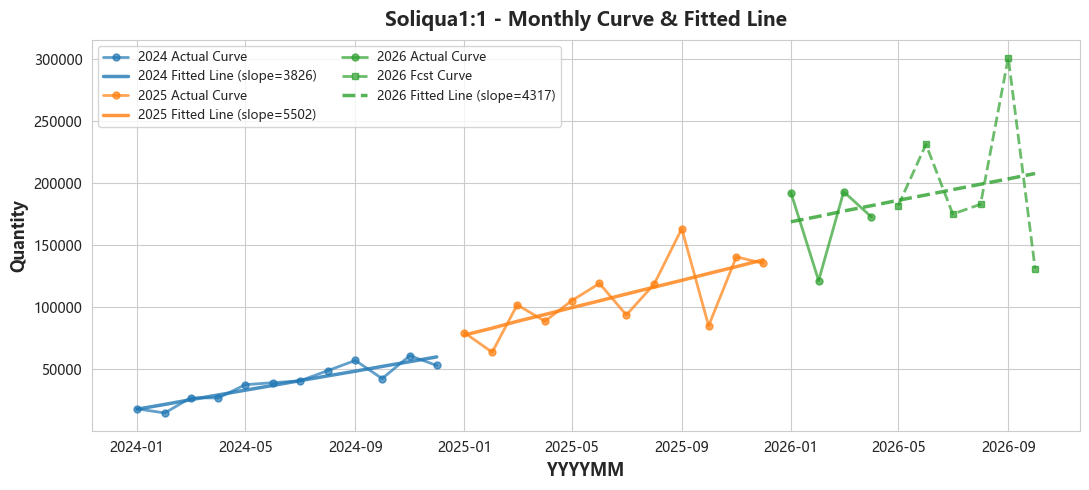

In [28]:
fit_results = {}
years = sorted(plot_df_170['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for year in years:
    year_df = plot_df_170[plot_df_170['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = plot_df_170[plot_df_170['年份'] == year].sort_values('bizym')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        plt.plot(hist_data['bizym'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year} Actual Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        plt.plot(pred_data_year['bizym'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year} Fcst Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        plt.plot(result['df']['bizym'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year} Fitted Line (slope={result["slope"]:.0f})',
                alpha=0.8)

plt.xlabel('YYYYMM', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Soliqua1:1 - Monthly Curve & Fitted Line', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

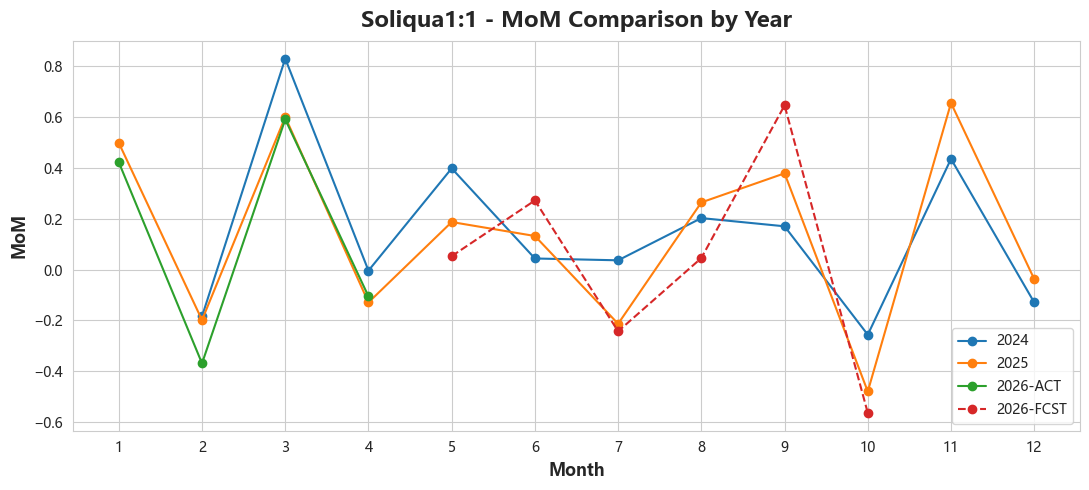

In [29]:
for y in sorted(plot_df_170["年份"].unique()):
    sub = plot_df_170[plot_df_170["年份"] == y].sort_values("月份")
    if y==2026:
        plt.plot(sub[sub['类型'] == '历史实际值']["月份"], sub[sub['类型'] == '历史实际值']["mom"], label=str(y)+'-ACT', marker='o')
        plt.plot(sub[sub['类型'] == '未来预测值']["月份"], sub[sub['类型'] == '未来预测值']["mom"], label=str(y)+'-FCST', marker='o',linestyle='--')
    else:
        plt.plot(sub["月份"], sub["mom"], label=str(y), marker='o')

plt.xlabel("Month")
plt.ylabel("MoM")
plt.title("Soliqua1:1 - MoM Comparison by Year")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

---
*根据合理性评估是否需要手动修正

In [ ]:
pred_ensemble_corrected = pred_ensemble.copy()
pred_ensemble_corrected[0] = pred_ensemble[0] * 1.15
pred_ensemble_corrected[1] = pred_ensemble[1] * 1
pred_ensemble_corrected[2] = pred_ensemble[2] * 0.85
pred_ensemble_corrected

---

### 2.10. 置信区间

In [30]:
df_fcst_170 = plot_df_170[plot_df_170['类型']>='未来预测值'][['bizym','qty']]
df_fcst_170

,bizym,qty
14,2026-05-01,181649.593426
17,2026-06-01,231023.013679
20,2026-07-01,174873.359228
23,2026-08-01,182773.045434
26,2026-09-01,300830.404964
29,2026-10-01,131032.579163


In [31]:
import random
random.seed(331)
df_fcst_170['lb'] = df_fcst_170['qty'].apply(lambda x: x*(1-random.uniform(0.03,0.05)))
df_fcst_170['ub'] = df_fcst_170['qty'].apply(lambda x: x*(1+random.uniform(0.03,0.05)))
df_fcst_170 = df_fcst_170.round(decimals=0)
df_fcst_170

,bizym,qty,lb,ub
14,2026-05-01,181650.0,173164.0,188798.0
17,2026-06-01,231023.0,222609.0,242411.0
20,2026-07-01,174873.0,169028.0,182439.0
23,2026-08-01,182773.0,174109.0,190388.0
26,2026-09-01,300830.0,288004.0,315072.0
29,2026-10-01,131033.0,125403.0,136918.0


## 3. 171规格预测

### 3.1. by月聚合

In [48]:
df_monthly = (df_raw[df_raw['prodmdmcode']=='171'].groupby('bizym', as_index=False)
    .agg(qty=('qty', 'sum'))
    .sort_values('bizym')
    .reset_index(drop=True)
)
df_monthly.head()

,bizym,qty
0,2024-01-01,6391.0
1,2024-02-01,7228.0
2,2024-03-01,9800.0
3,2024-04-01,12440.0
4,2024-05-01,14123.0


In [49]:
fig = px.scatter(data_frame=df_monthly, x=df_monthly['bizym'], y=df_monthly['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=df_monthly['bizym'], 
                        y=df_monthly['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False
                        ))

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2025-01-01'), x1=pd.Timestamp('2025-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",  # 关键：yref=paper 让 y 坐标用 0-1 相对值
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2026-01-01'), x1=pd.Timestamp('2026-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)


fig.add_annotation(
    x=pd.Timestamp('2025-01-01'), y=1,
    xref="x", yref="paper",
    text="2025", showarrow=False,
    yshift=5,  # 文字位置稍微上移
    font=dict(size=12, color='#E74C3C')
)

fig.add_annotation(
    x=pd.Timestamp('2026-01-01'), y=1,
    xref="x", yref="paper",
    text="2026", showarrow=False,
    yshift=5,
    font=dict(size=12, color='#E74C3C')
)


fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title='Soliqua 2:1 (171)',
                xaxis_tickangle=45,
                width=800, 
                height=400 )

In [50]:
print(f"✓ 月度数据准备完成，共{len(df_monthly)}个月")
print(f"✓ 时间范围: {df_monthly['bizym'].min().strftime('%Y-%m')} ~ {df_monthly['bizym'].max().strftime('%Y-%m')}")

✓ 月度数据准备完成，共29个月
✓ 时间范围: 2024-01 ~ 2026-05


### 3.2. 特征工程

In [51]:
# 添加基础时间特征
df_monthly['month'] = df_monthly['bizym'].dt.month
df_monthly['year'] = df_monthly['bizym'].dt.year

# 月度活跃医疗机构数
monthly_active_171 = (
    df_raw[(df_raw['prodmdmcode']=='171') & (df_raw['qty']>0)]
    .groupby('bizym')['tomdphncode']
    .nunique()
    .rename('活跃医疗机构数')
    .reset_index()
)
monthly_active_171['bizym'] = monthly_active_171['bizym'].dt.to_period('M').dt.to_timestamp()

df_monthly = df_monthly.merge(monthly_active_171, on='bizym', how='left')
df_monthly

,bizym,qty,month,year,活跃医疗机构数
0,2024-01-01,6391.0,1,2024,257
1,2024-02-01,7228.0,2,2024,190
2,2024-03-01,9800.0,3,2024,271
3,2024-04-01,12440.0,4,2024,253
4,2024-05-01,14123.0,5,2024,293
5,2024-06-01,15394.0,6,2024,294
6,2024-07-01,17929.0,7,2024,330
7,2024-08-01,18228.0,8,2024,373
8,2024-09-01,22595.0,9,2024,418
9,2024-10-01,18710.0,10,2024,392


In [52]:
def create_holistic_samples_171(df, target_date):
    """为指定预测起点创建未来6个月预测样本（含医疗机构数、单院产量、斜率衰减因子）"""

    # 1. 准备月份索引
    future_months      = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    same_period_ly     = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    recent_6m          = pd.date_range(target_date - pd.DateOffset(months=5),  periods=6, freq='MS')
    future_month_nums  = [m.month for m in future_months]

    # 2. 把 bizym 设为索引，截取历史数据
    df_idx  = df.set_index('bizym')
    df_hist = df_idx[df_idx.index <= target_date]

    # 3. 一次性取出所有月份的销量与医疗机构数
    sales_ly = df_hist['qty'].reindex(same_period_ly)
    hosp_ly  = df_hist['活跃医疗机构数'].reindex(same_period_ly)
    sales_re = df_hist['qty'].reindex(recent_6m)
    hosp_re  = df_hist['活跃医疗机构数'].reindex(recent_6m)

    # 4. 单院产量
    unit_ly = (sales_ly / hosp_ly).where(hosp_ly > 0)
    unit_re = (sales_re / hosp_re).where(hosp_re > 0)

    # 5. 整体斜率
    def slope_r(y):
        y = np.asarray(y, dtype=float)
        mask = ~np.isnan(y)
        if mask.sum() < 2:
            return np.nan, np.nan
        s, _, r, _, _ = stats.linregress(np.arange(len(y))[mask], y[mask])
        return s, r

    slope_ly, r_ly   = slope_r(sales_ly.values)
    slope_re, r_re   = slope_r(sales_re.values)

    # 6. 斜率衰减因子
    if not (np.isnan(slope_ly) or np.isnan(slope_re)) and abs(slope_ly) > 1:
        slope_decay_factor = float(np.clip(slope_re / slope_ly, 0.3, 2.0))
    else:
        slope_decay_factor = 1.0

    # 7. 预测起点数据
    base_sale = float(df_hist['qty'].get(target_date, np.nan))
    base_hosp = float(df_hist['活跃医疗机构数'].get(target_date, np.nan))
    base_unit = base_sale / base_hosp if base_hosp > 0 and pd.notna(base_hosp) else np.nan

    # 8. 组装整体特征
    features = {
        'ly_销量_均值':      np.nanmean(sales_ly),   'ly_销量_标准差':   np.nanstd(sales_ly),
        'ly_医疗机构数_均值': np.nanmean(hosp_ly),   'ly_单院产量_均值': np.nanmean(unit_ly),
        'ly_整体斜率':        slope_ly,               'ly_R方':           r_ly,
        'rec_销量_均值':      np.nanmean(sales_re),  'rec_销量_标准差':  np.nanstd(sales_re),
        'rec_医疗机构数_均值':np.nanmean(hosp_re),   'rec_单院产量_均值':np.nanmean(unit_re),
        'rec_整体斜率':       slope_re,               'rec_R方':          r_re,
        # 'base_销量':          base_sale,              'base_医疗机构数':  base_hosp,
        'base_单院产量':      base_unit,
        '未来_起始月':        future_month_nums[0],   '未来_结束月':      future_month_nums[-1],
        '斜率衰减因子':       slope_decay_factor,     # '历史YoY目标':      target_yoy_mean,
    }

    # 月份 one-hot 编码
    month_names = ['jan','feb','mar','apr','may','jun',
                   'jul','aug','sep','oct','nov','dec']
    for i, m in enumerate(future_month_nums, 1):
        features[f'future_M{i}_is_{month_names[m-1]}'] = 1

    # 逐月细粒度特征
    for i in range(6):
        features[f'ly_M{i+1}_销量']      = sales_ly.iloc[i]
        features[f'ly_M{i+1}_医疗机构数'] = hosp_ly.iloc[i]
        features[f'rec_M{i+1}_销量']      = sales_re.iloc[i]
        features[f'rec_M{i+1}_医疗机构数']= hosp_re.iloc[i]

    # 9. 提取目标
    targets_abs = df_idx['qty'].reindex(future_months).tolist()
    targets_mom = []
    prev = base_sale
    for s in targets_abs:
        if pd.notna(s) and pd.notna(prev) and prev > 0:
            targets_mom.append((s - prev) / prev * 100)
            prev = s
        else:
            targets_mom.append(np.nan)

    return features, targets_abs, targets_mom, future_months

In [53]:
train_dates = pd.date_range(TRAIN_START, TRAIN_END, freq='MS')

train_samples = []
train_targets_abs = []
train_targets_mom = []

for date in train_dates:
    features, targets_abs, targets_mom, _ = create_holistic_samples_171(df_monthly, date)
    
    # 检查 label 是否有值
    if not any(np.isnan(targets_abs)) and not any(np.isnan(targets_mom)):
        train_samples.append(features)
        train_targets_abs.append(targets_abs)
        train_targets_mom.append(targets_mom)
    else:
        nan_abs_idx = [i+1 for i, v in enumerate(targets_abs) if np.isnan(v)]
        nan_mom_idx = [i+1 for i, v in enumerate(targets_mom) if np.isnan(v)]
        raise ValueError(
            f"目标值不完整(起点日期: {date.strftime('%Y-%m')})；"
            f"销量缺失月份(第几个月): {nan_abs_idx}；"
            f"环比缺失月份(第几个月): {nan_mom_idx}。"
        )

print(f"✓ 生成{len(train_samples)}个训练样本")

# 转为DataFrame
train_X = pd.DataFrame(train_samples)
train_y_abs = np.array(train_targets_abs)
train_y_mom = np.array(train_targets_mom)

print(f"  特征维度: {train_X.shape}")
print(f"  特征数量: {train_X.shape[1]}")

✓ 生成13个训练样本
  特征维度: (13, 112)
  特征数量: 112


### 3.3. 缺失值填充

In [54]:
# 检查缺失值情况
nan_counts = train_X.isna().sum()
print(f"\n训练数据缺失值统计(前10个):")
if nan_counts.sum() > 0:
    for col, count in nan_counts[nan_counts > 0].head(10).items():
        print(f"  - {col}: {count}个缺失值")


训练数据缺失值统计(前10个):
  - future_M1_is_nov: 11个缺失值
  - future_M2_is_dec: 11个缺失值
  - future_M3_is_jan: 11个缺失值
  - future_M4_is_feb: 11个缺失值
  - future_M5_is_mar: 11个缺失值
  - future_M6_is_apr: 11个缺失值
  - ly_M1_销量: 2个缺失值
  - ly_M1_医疗机构数: 2个缺失值
  - ly_M2_销量: 1个缺失值
  - ly_M2_医疗机构数: 1个缺失值


In [55]:
train_X_filled = train_X.copy()

for col in train_X_filled.columns:
    if train_X_filled[col].isna().all():
        train_X_filled[col] = 0
    elif '斜率' in col : # 0填充
        n_missing = train_X_filled[col].isna().sum()
        if n_missing > 0:
            train_X_filled[col] = train_X_filled[col].fillna(0)
    else:
        if train_X_filled[col].notna().any(): # 均值填充
            train_X_filled[col] = train_X_filled[col].fillna(train_X_filled[col].mean())
        else:
            train_X_filled[col] = 0

if train_X_filled.isna().sum().sum() == 0:
    print(f"\n✓ 缺失值填充完成")


✓ 缺失值填充完成


### 3.4. 标准化

In [56]:
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_filled)

print(f"✓ 特征标准化完成")

✓ 特征标准化完成


### 3.5. 模型训练

In [57]:
models_abs = []
for i in range(6):
    model = Ridge(alpha=10.0, random_state=42)  # ⭐ 增大alpha抑制过拟合
    model.fit(train_X_scaled, train_y_abs[:, i])
    models_abs.append(model)

models_mom = []
for i in range(6):
    model = Ridge(alpha=10.0, random_state=42)
    model.fit(train_X_scaled, train_y_mom[:, i])
    models_mom.append(model)

print(f"✓ 6个绝对值Ridge模型训练完成(alpha=10.0)")
print(f"✓ 6个环比Ridge模型训练完成(alpha=10.0)")

✓ 6个绝对值Ridge模型训练完成(alpha=10.0)
✓ 6个环比Ridge模型训练完成(alpha=10.0)


### 3.6. 预测未来6个月

In [58]:
feats_pred, _, _, future_months = create_holistic_samples_171(df_monthly, PRED_START)
X_pred_filled = fill_features(
    pd.DataFrame([feats_pred]),
    df_train=train_X_filled,
    train_columns=train_X_filled.columns,
)
X_pred_scaled = scaler_X.transform(X_pred_filled)
pred_abs      = predict_ensemble(models_abs, X_pred_scaled)
pred_mom_r    = predict_ensemble(models_mom, X_pred_scaled)
base_sale     = lookup_qty(df_monthly, PRED_START)
pred_from_mom = chain_mom_to_abs(base_sale, pred_mom_r)

**新增：YoY约束**

In [60]:
def calc_recent_yoy_mean(df, target_date, n_months=12):
    """计算 target_date 往前 n_months 个月的 YoY 均值"""
    recent_months = pd.date_range(target_date - pd.DateOffset(months=n_months - 1), periods=n_months, freq='MS')
    df_idx = df.set_index('bizym')['qty']
    
    yoy_list = []
    for m in recent_months:
        curr = df_idx.get(m, np.nan)
        prev = df_idx.get(m - pd.DateOffset(years=1), np.nan)
        if pd.notna(curr) and pd.notna(prev) and prev > 0:
            yoy_list.append((curr - prev) / prev * 100)
    
    return (np.mean(yoy_list), np.std(yoy_list)) if yoy_list else (10.0, 5.0)


target_yoy_mean, target_yoy_std = calc_recent_yoy_mean(df_monthly, PRED_START)
print(f"✓ 过去12个月YoY均值: {target_yoy_mean:.2f}%")
print(f"✓ 过去12个月YoY标准差: {target_yoy_std:.2f}%")

✓ 过去12个月YoY均值: 163.23%
✓ 过去12个月YoY标准差: 42.86%


In [61]:
# 根据去年同期 + 过去一年YoY均值推算未来销量
def calc_yoy_constrained_preds(df, future_months, target_yoy_mean):
    df_idx = df.set_index('bizym')['qty']
    preds = []
    for m in future_months:
        last_year_sale = df_idx.get(m - pd.DateOffset(years=1), np.nan)
        preds.append(
            last_year_sale * (1 + target_yoy_mean / 100) if pd.notna(last_year_sale) and last_year_sale > 0 else np.nan
        )
    return np.array(preds)

pred_yoy = calc_yoy_constrained_preds(df_monthly, future_months, target_yoy_mean)
pred_yoy

array([105590.38735917, 138404.9304953 , 103050.19530668, 135625.19701609,
       188740.21798519,  98122.48595718])

In [62]:
pred_ensemble = mix_three_way(pred_from_mom, pred_abs, pred_yoy, 0.1, 0.4, 0.5)

### 3.7. 系数校正（Optional）

In [63]:
recent_3m = df_monthly[
    (df_monthly['bizym'] >= PRED_START + pd.DateOffset(months=-2)) &
    (df_monthly['bizym'] <= PRED_START + pd.DateOffset(months=0))
]['qty'].values

recent_avg = np.mean(recent_3m)
pred_avg = np.mean(pred_ensemble)

print(f"  R3M月平均: {recent_avg:.0f}")
print(f"  N6M预测平均: {pred_avg:.0f}")
print(f"  N6M vs R3M: {pred_avg / recent_avg:.1f}")

  R3M月平均: 78359
  N6M预测平均: 119656
  N6M vs R3M: 1.5


In [64]:
if pred_avg > recent_avg * 1.1:
    adjustment_factor = (recent_avg * 1.1) / pred_avg
    print(f"  ⚠️  预测水平偏高，执行整体下调(系数={adjustment_factor:.2f})")
    
    pred_ensemble = pred_ensemble * adjustment_factor
    
    print(f"  校准后平均: {np.mean(pred_ensemble):.0f}")
else:
    print(f"  ✓ 预测水平合理，无需调整")

  ⚠️  预测水平偏高，执行整体下调(系数=0.72)
  校准后平均: 86195


In [65]:
# 历史数据
plot_df_171 = plot_df_170 = df_monthly[df_monthly['bizym']<=PRED_START][['bizym', 'qty']].copy()
plot_df_171['年份'] = plot_df_171['bizym'].dt.year
plot_df_171['月份'] = plot_df_171['bizym'].dt.month
plot_df_171['类型'] = '历史实际值'

# 添加预测数据
pred_data = pd.DataFrame({
    'bizym': future_months,
    'qty': pred_ensemble,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值'
})
plot_df_171 = pd.concat([plot_df_171, pred_data], ignore_index=True)

# 计算YoY
plot_df_171 = plot_df_171.sort_values(['月份', '年份'])
yoy_list = []
for month in range(1, 13):
    month_data = plot_df_171[plot_df_171['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

plot_df_171 = pd.concat(yoy_list, ignore_index=True).sort_values('bizym')

# 计算MoM
plot_df_171['mom'] = plot_df_171['qty'].pct_change()
plot_df_171


,bizym,qty,年份,月份,类型,YoY,mom
0,2024-01-01,6391.000000,2024,1,历史实际值,NaN,NaN
3,2024-02-01,7228.000000,2024,2,历史实际值,NaN,0.130965
6,2024-03-01,9800.000000,2024,3,历史实际值,NaN,0.355838
9,2024-04-01,12440.000000,2024,4,历史实际值,NaN,0.269388
12,2024-05-01,14123.000000,2024,5,历史实际值,NaN,0.135289
15,2024-06-01,15394.000000,2024,6,历史实际值,NaN,0.089995
18,2024-07-01,17929.000000,2024,7,历史实际值,NaN,0.164675
21,2024-08-01,18228.000000,2024,8,历史实际值,NaN,0.016677
24,2024-09-01,22595.000000,2024,9,历史实际值,NaN,0.239576
27,2024-10-01,18710.000000,2024,10,历史实际值,NaN,-0.171941


In [66]:
print(f"\n【预测结果】")
print("="*110)
print(f"{'month':<12} {'预测销量':>12} {'环比%':>10} {'YoY%':>10}")
print("="*110)

for i, month in enumerate(future_months):
    # 计算环比
    if i == 0:
        mom_pct = (pred_ensemble[i] - base_sale) / base_sale * 100
    else:
        mom_pct = (pred_ensemble[i] - pred_ensemble[i-1]) / pred_ensemble[i-1] * 100
    
    # 获取YoY
    yoy_idx = plot_df_171[(plot_df_171['bizym'] == month) & (plot_df_171['类型'] == '未来预测值')].index
    if len(yoy_idx) > 0:
        yoy_val = plot_df_171.loc[yoy_idx[0], 'YoY']
        yoy_str = f"{yoy_val:+.2f}%" if not np.isnan(yoy_val) else "N/A"
    else:
        yoy_str = "N/A"
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_ensemble[i]:>12.0f} {mom_pct:>12.2f}% {yoy_str:>12}")

print("="*110)


【预测结果】
month                预测销量        环比%       YoY%
2026-05             72961       -17.80%      +81.89%
2026-06             83328        14.21%      +58.48%
2026-07             80745        -3.10%     +106.26%
2026-08             83832         3.82%      +62.71%
2026-09            118460        41.31%      +65.21%
2026-10             77846       -34.28%     +108.84%


### 3.8. 可视化观察合理性

In [67]:
fig = px.scatter(data_frame=plot_df_171, x=plot_df_171['bizym'], y=plot_df_171['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=plot_df_171[plot_df_171['类型']=='历史实际值']['bizym'], 
                        y=plot_df_171[plot_df_171['类型']=='历史实际值']['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False
                        ))
fig.add_trace(go.Scatter(x=plot_df_171.iloc[-7:, 0], 
                        y=plot_df_171.iloc[-7:, 1], 
                        mode='lines', 
                        line=dict(color='royalblue', width=2),
                        showlegend=False
                        ))

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2025-01-01'), x1=pd.Timestamp('2025-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",  # 关键：yref=paper 让 y 坐标用 0-1 相对值
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2026-01-01'), x1=pd.Timestamp('2026-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)


fig.add_annotation(
    x=pd.Timestamp('2025-01-01'), y=1,
    xref="x", yref="paper",
    text="2025", showarrow=False,
    yshift=5,  # 文字位置稍微上移
    font=dict(size=12, color='#E74C3C')
)

fig.add_annotation(
    x=pd.Timestamp('2026-01-01'), y=1,
    xref="x", yref="paper",
    text="2026", showarrow=False,
    yshift=5,
    font=dict(size=12, color='#E74C3C')
)


fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title='Soliqua 2:1 (171)',
                xaxis_tickangle=45,
                width=800, 
                height=400 )

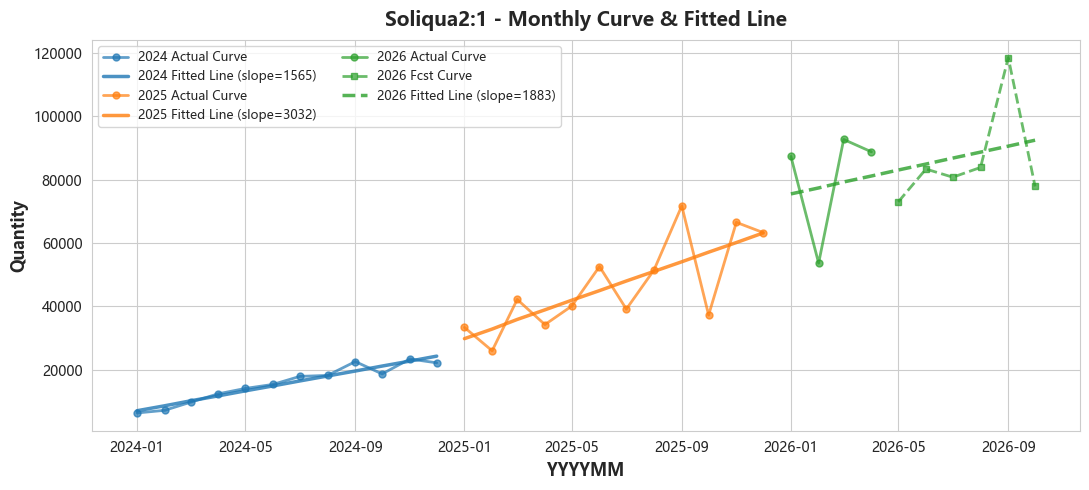

In [68]:
fit_results = {}
years = sorted(plot_df_171['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for year in years:
    year_df = plot_df_171[plot_df_171['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = plot_df_171[plot_df_171['年份'] == year].sort_values('bizym')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        plt.plot(hist_data['bizym'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year} Actual Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        plt.plot(pred_data_year['bizym'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year} Fcst Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        plt.plot(result['df']['bizym'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year} Fitted Line (slope={result["slope"]:.0f})',
                alpha=0.8)

plt.xlabel('YYYYMM', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Soliqua2:1 - Monthly Curve & Fitted Line', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

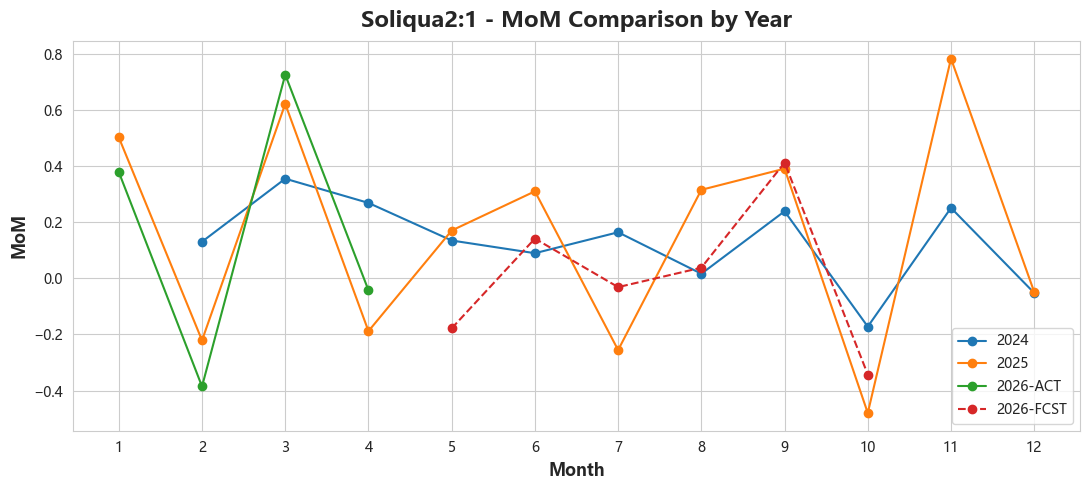

In [69]:
for y in sorted(plot_df_171["年份"].unique()):
    sub = plot_df_171[plot_df_171["年份"] == y].sort_values("月份")
    if y==2026:
        plt.plot(sub[sub['类型'] == '历史实际值']["月份"], sub[sub['类型'] == '历史实际值']["mom"], label=str(y)+'-ACT', marker='o')
        plt.plot(sub[sub['类型'] == '未来预测值']["月份"], sub[sub['类型'] == '未来预测值']["mom"], label=str(y)+'-FCST', marker='o',linestyle='--')
    else:
        plt.plot(sub["月份"], sub["mom"], label=str(y), marker='o')

plt.xlabel("Month")
plt.ylabel("MoM")
plt.title("Soliqua2:1 - MoM Comparison by Year")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

---
*根据合理性评估是否需要手动修正

In [ ]:
pred_ensemble_corrected = pred_ensemble.copy()
pred_ensemble_corrected[0] = pred_ensemble[0] * 1.15
pred_ensemble_corrected[1] = pred_ensemble[1] * 1
pred_ensemble_corrected[2] = pred_ensemble[2] * 0.85
pred_ensemble_corrected

---

### 3.9. 置信区间

In [70]:
df_fcst_171 = plot_df_171[plot_df_171['类型']>='未来预测值'][['bizym','qty']]
df_fcst_171

,bizym,qty
14,2026-05-01,72961.347067
17,2026-06-01,83327.573898
20,2026-07-01,80744.809181
23,2026-08-01,83832.189654
26,2026-09-01,118459.722584
29,2026-10-01,77845.957616


In [71]:
import random
random.seed(331)
df_fcst_171['lb'] = df_fcst_171['qty'].apply(lambda x: x*(1-random.uniform(0.03,0.05)))
df_fcst_171['ub'] = df_fcst_171['qty'].apply(lambda x: x*(1+random.uniform(0.03,0.05)))
df_fcst_171 = df_fcst_171.round(decimals=0)
df_fcst_171

,bizym,qty,lb,ub
14,2026-05-01,72961.0,69553.0,75833.0
17,2026-06-01,83328.0,80293.0,87435.0
20,2026-07-01,80745.0,78046.0,84238.0
23,2026-08-01,83832.0,79858.0,87325.0
26,2026-09-01,118460.0,113409.0,124068.0
29,2026-10-01,77846.0,74501.0,81343.0
